In [3]:
import pandas as pd

# Import CSV file into a DataFrame
df = pd.read_csv('D:/Users/S4129857/hotel_bookings_data/hotel_bookings.csv')  

# Show the head of the DataFrame
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0.0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0.0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0.0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0.0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0.0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [4]:
#Quick check to ensure it's loaded correctly
print("Shape of loaded data:", df.shape)
#Check for duplicates and remove them
df = df.drop_duplicates()
# Remove entries with zero guests (adults + children + babies = 0)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
#Check for missing values in all columns
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values[missing_values > 0])


Shape of loaded data: (119392, 32)
Missing values:
 is_canceled               1
arrival_date_month        1
country                 449
agent                 12141
company               81993
dtype: int64


In [6]:
#Drop rows where arrival_date_month, children, or country is missing
df = df.dropna(subset=['arrival_date_month', 'children', 'country'])
#Replace missing 'agent' values with the column's mean
agent_mean = df['agent'].mean()
df['agent'].fillna(agent_mean, inplace=True)
#Drop the 'company' column
df.drop('company', axis=1, inplace=True)
#Convert 'agent' to int if desired
df['agent'] = df['agent'].astype(int)
#Save the cleaned DataFrame to a new CSV file
df.to_csv('D:/Users/S4129857/hotel_bookings_data/cleaned version.csv', index=False)

C:\Users\SK\AppData\Local\Temp\ipykernel_1984\2205119730.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(agent_mean, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x1ad7038f750>,
 'caps': [<matplotlib.lines.Line2D at 0x1ad7038f9d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ad7038f610>],
 'medians': [<matplotlib.lines.Line2D at 0x1ad7038fc50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ad7038fd90>],
 'means': []}

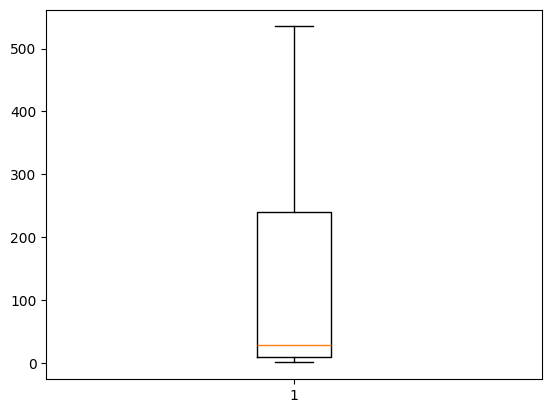

In [7]:
#boxplot of agent
import matplotlib.pyplot as plt
plt.boxplot(df['agent'])

In [9]:
#import cleaned data frame
cleaned_version = pd.read_csv('D:/Users/S4129857/hotel_bookings_data/cleaned version.csv')  
cleaned_version.head()
# General stats for both numeric and object types
summary = cleaned_version.describe(include='all').transpose()

# Add mode for each column (including categorical)
modes = cleaned_version.mode().iloc[0]  # First mode if multiple exist
summary['mode'] = modes

# Show the summary
summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,mode
hotel,86780,2,City Hotel,53266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,City Hotel
is_canceled,86779.0,NaN,NaN,NaN,0.2763,0.447169,0.0,0.0,0.0,1.0,1.0,0.0
lead_time,86780.0,NaN,NaN,NaN,80.492279,97.881144,0.0,12.0,50.0,125.0,10000.0,0
arrival_date_year,86780.0,NaN,NaN,NaN,2016.188615,6.821376,17.0,2016.0,2016.0,2017.0,2017.0,2016
arrival_date_month,86780,17,August,11217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,August
arrival_date_week_number,86780.0,NaN,NaN,NaN,26.838281,13.649992,1.0,16.0,27.0,37.0,53.0,33
arrival_date_day_of_month,86780.0,NaN,NaN,NaN,15.818126,8.834689,1.0,8.0,16.0,23.0,31.0,17
stays_in_weekend_nights,86780.0,NaN,NaN,NaN,1.006718,1.024263,0.0,0.0,1.0,2.0,16.0,0
stays_in_week_nights,86780.0,NaN,NaN,NaN,2.62723,2.030064,0.0,1.0,2.0,4.0,40.0,1
adults,86780.0,NaN,NaN,NaN,1.882,0.621168,0.0,2.0,2.0,2.0,55.0,2


C:\Users\SK\AppData\Local\Temp\ipykernel_1984\3627669933.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SK\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


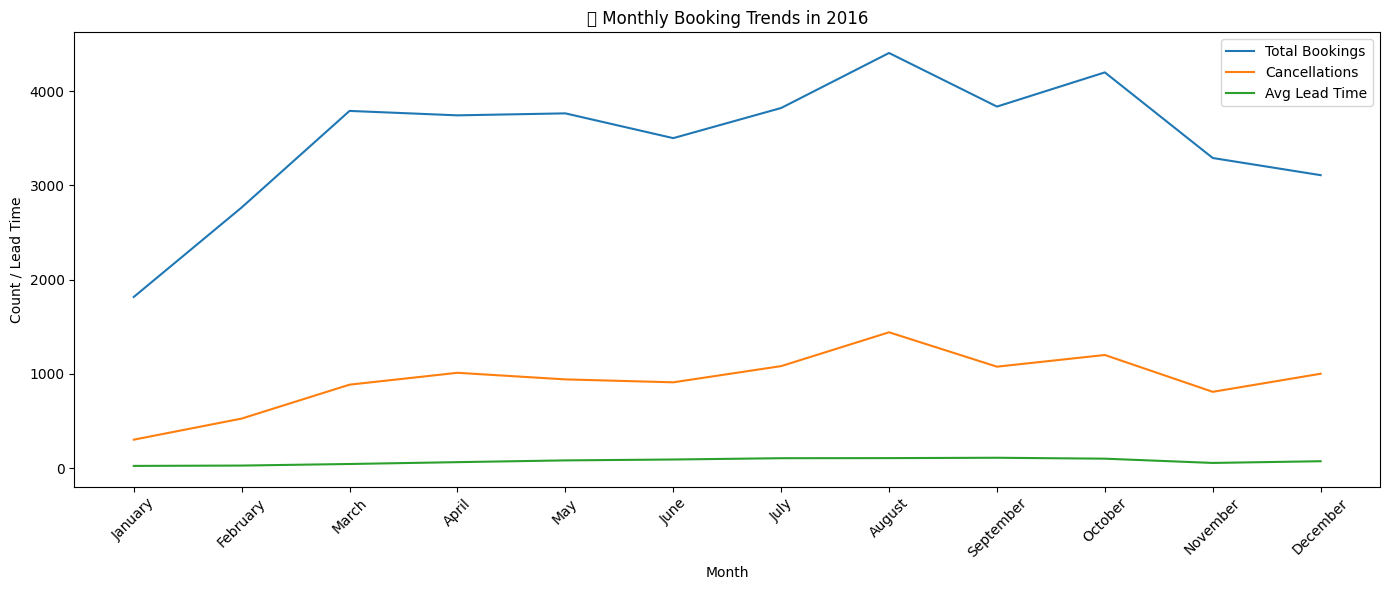

In [10]:
#Task 02
#question 1
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only bookings from 2016
df_2016 = cleaned_version[cleaned_version['arrival_date_year'] == 2016]

# Group by month, count total bookings, cancellations, and mean lead time
monthly_2016 = df_2016.groupby('arrival_date_month').agg({
    'is_canceled': ['count', 'sum'],
    'lead_time': 'mean'
}).reset_index()

# Clean column names
monthly_2016.columns = ['month', 'total_bookings', 'cancellations', 'avg_lead_time']

# Optional: Sort months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_2016['month'] = pd.Categorical(monthly_2016['month'], categories=month_order, ordered=True)
monthly_2016 = monthly_2016.sort_values('month')

# Plotting
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_2016, x='month', y='total_bookings', label='Total Bookings')
sns.lineplot(data=monthly_2016, x='month', y='cancellations', label='Cancellations')
sns.lineplot(data=monthly_2016, x='month', y='avg_lead_time', label='Avg Lead Time')

plt.title('Monthly Booking Trends in 2016')
plt.xlabel('Month')
plt.ylabel('Count / Lead Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


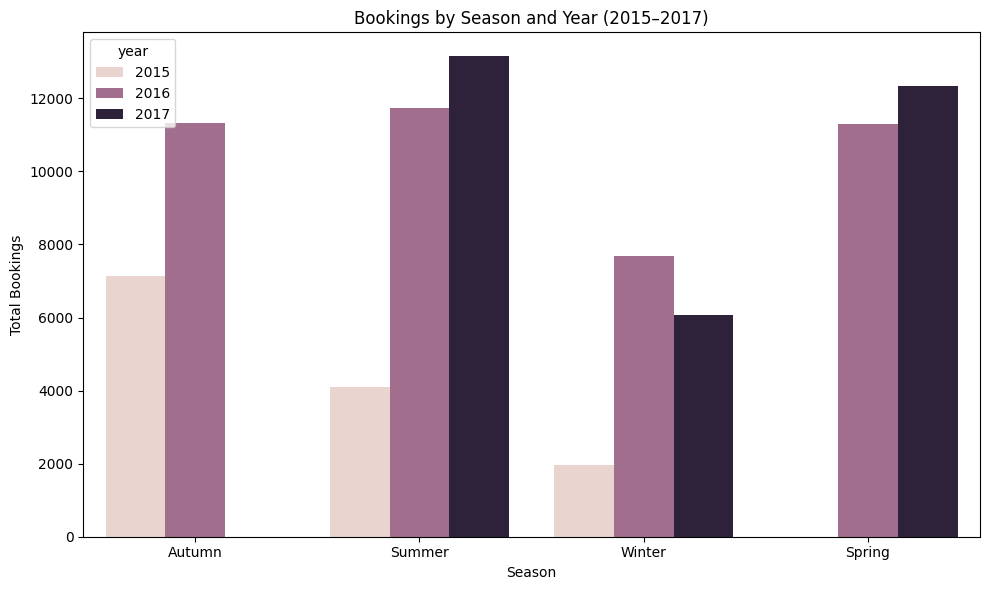

In [27]:
#question 2
# Define seasons
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}
cleaned_version['season'] = cleaned_version['arrival_date_month'].map(season_map)

# Filter years 2015 to 2017
df_seasonal = cleaned_version[cleaned_version['arrival_date_year'].isin([2015, 2016, 2017])]

# Group and summarize
seasonal_summary = df_seasonal.groupby(['arrival_date_year', 'season']).agg({
    'is_canceled': ['count', 'sum']
}).reset_index()

# Clean column names
seasonal_summary.columns = ['year', 'season', 'total_bookings', 'cancellations']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=seasonal_summary, x='season', y='total_bookings', hue='year')
plt.title('Bookings by Season and Year (2015–2017)')
plt.ylabel('Total Bookings')
plt.xlabel('Season')
plt.tight_layout()
plt.show()


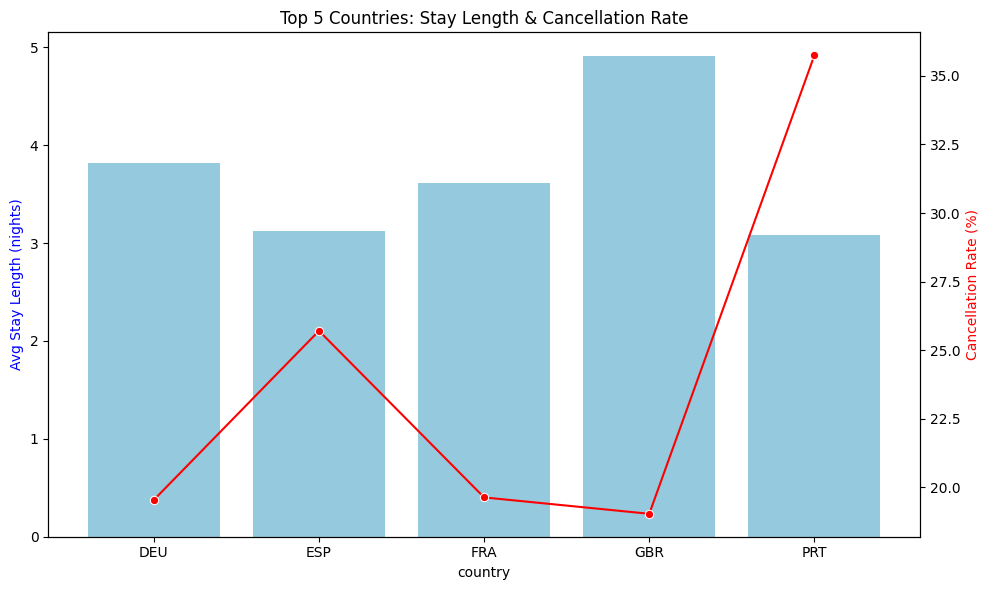

In [12]:
#question 3
# Total guests = adults + children + babies
cleaned_version['total_stay_nights'] = cleaned_version['stays_in_week_nights'] + cleaned_version['stays_in_weekend_nights']

# Top 5 countries by booking count
top_countries = cleaned_version['country'].value_counts().head(5).index
df_top_countries = cleaned_version[cleaned_version['country'].isin(top_countries)]

# Group and summarize
country_summary = df_top_countries.groupby('country').agg({
    'is_canceled': ['count', 'sum'],
    'total_stay_nights': 'mean'
}).reset_index()

# Clean column names
country_summary.columns = ['country', 'total_bookings', 'cancellations', 'avg_stay_length']
country_summary['cancellation_rate'] = (country_summary['cancellations'] / country_summary['total_bookings']) * 100

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(data=country_summary, x='country', y='avg_stay_length', ax=ax1, color='skyblue')
ax1.set_ylabel('Avg Stay Length (nights)', color='blue')
ax1.set_title('Top 5 Countries: Stay Length & Cancellation Rate')

# Second y-axis
ax2 = ax1.twinx()
sns.lineplot(data=country_summary, x='country', y='cancellation_rate', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Cancellation Rate (%)', color='red')

plt.tight_layout()
plt.show()
